In [122]:
import time

# --------- GLOBAL TIMER ----------
start_total_time = time.time()

section_times = {}

def start_timer(section_name):
    section_times[section_name] = {"start": time.time()}

def end_timer(section_name):
    section_times[section_name]["end"] = time.time()
    section_times[section_name]["duration"] = (
        section_times[section_name]["end"] - section_times[section_name]["start"]
    )

# --------- SECTION NAMES ----------
section_names = {
    "Section 1": "SYSTEM SETUP & HARDWARE CHECK",
    "Section 2": "IMPORTS & CONFIG",
    "Section 3": "DATA LOADING",
    "Section 4": "EDA",
    "Section 5": "DATA CLEANING",
    "Section 6": "FEATURE ENGINEERING",
    "Section 7": "ENCODING",
    "Section 8": "SPLIT & SCALING",
    "Section 9": "EVALUATION UTILS",

    # ✅ YOU WERE RIGHT — FIXED NUMBERING HERE
    "Section 10": "LOGISTIC REGRESSION",
    "Section 11": "DECISION TREE",
    "Section 12": "RANDOM FOREST",
    "Section 13": "XGBOOST",
    "Section 14": "LIGHTGBM",
    "Section 15": "CATBOOST",
    "Section 16": "STACKING",
    "Section 17": "MODEL COMPARISON",
    "Section 18": "THRESHOLD OPTIMIZATION",
    "Section 19": "FINAL CV CHECK",
    "Section 20": "OPTUNA TUNING",
    "Section 21": "TUNED LOGISTIC",
    "Section 22": "THRESHOLD (TUNED)",
    "Section 23": "SHAP",
    "Section 24": "ANN TRAINING",
    "Section 25": "ANN EVALUATION",
    "Section 26": "FINAL SUMMARY",
    "Section 27": "BUSINESS ANALYSIS",
    "Section 28": "MODEL SAVING",
    "Section 29": "SHAP SINGLE",
    "Section 30": "SHAP GLOBAL"
}

In [123]:
# ============================================================
# SECTION 1: SYSTEM SETUP & HARDWARE CHECK
# ============================================================

"""
Purpose:
--------
This section verifies whether GPU is available for accelerating models
like Neural Networks, XGBoost, and CatBoost.

Why important?
--------------
- GPU speeds up training significantly
- Ensures correct environment setup before running models
"""

start_timer("Section 1")

# --------- IMPORTS FOR HARDWARE CHECK ----------
import torch

# --------- GPU CHECK ----------
print("🔍 Checking hardware configuration...\n")

# PyTorch GPU check
torch_gpu_available = torch.cuda.is_available()
print(f"PyTorch GPU Available: {torch_gpu_available}")

if torch_gpu_available:
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU detected. Models will run on CPU.")

print("\n✅ System setup verification complete.\n")

end_timer("Section 1")

🔍 Checking hardware configuration...

PyTorch GPU Available: False
⚠️ No GPU detected. Models will run on CPU.

✅ System setup verification complete.



In [124]:
# ============================================================
# SECTION 2: IMPORTING LIBRARIES & GLOBAL CONFIGURATION
# ============================================================

"""
Purpose:
--------
Import all required libraries for:
- Data handling
- Visualization
- Machine Learning
- Evaluation

Also sets global configurations for cleaner output and consistency.
"""
start_timer("Section 2")

# --------- CORE LIBRARIES ----------
import pandas as pd
import numpy as np

# --------- VISUALIZATION ----------
import matplotlib.pyplot as plt
import seaborn as sns

# --------- MACHINE LEARNING ----------
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score, 
    recall_score,
    average_precision_score,
    accuracy_score
)

# --------- OPTIONAL / ADVANCED ----------
from sklearn.calibration import calibration_curve

# --------- SETTINGS ----------
import warnings
warnings.filterwarnings("ignore")

# Set consistent plot style
sns.set_theme(style="whitegrid")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import random

# --------- GLOBAL SEED ----------
random.seed(RANDOM_STATE)

import torch
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# --------- CROSS-VALIDATION SETUP (DEFINE ONCE) ----------
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("✅ All libraries imported and environment configured successfully.\n")
end_timer("Section 2")

✅ All libraries imported and environment configured successfully.



In [125]:
# ============================================================
# SECTION 3: DATA LOADING & INITIAL INSPECTION
# ============================================================

"""
Purpose:
--------
- Load dataset into memory
- Perform initial inspection of structure
- Understand feature types and basic properties

Why important?
--------------
- Ensures data is loaded correctly
- Helps identify issues early (types, missing values, etc.)
"""
start_timer("Section 3")
# --------- LOAD DATA ----------
DATA_PATH = "../data/raw/telco_churn.csv"

df = pd.read_csv(DATA_PATH)

print("✅ Dataset loaded successfully!\n")

# --------- BASIC OVERVIEW ----------
print("📌 Dataset Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("📌 First 5 Rows (Transposed for readability):")
display(df.head().T)

# --------- DATA TYPES & INFO ----------
print("\n📌 Dataset Information:")
df.info()

# --------- QUICK CHECK: DUPLICATES ----------
duplicate_count = df.duplicated().sum()
print(f"\n📌 Duplicate Rows: {duplicate_count}")

end_timer("Section 3")

✅ Dataset loaded successfully!

📌 Dataset Shape:
Rows: 7043, Columns: 21

📌 First 5 Rows (Transposed for readability):


,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No



📌 Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nu

📊 Statistical Summary (Numerical Features):


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


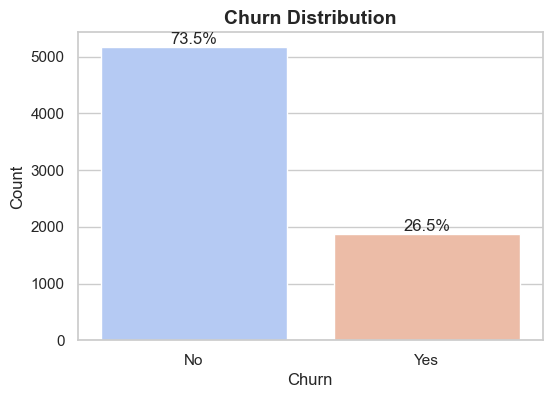


📌 Missing Values Per Column:


Series([], dtype: int64)

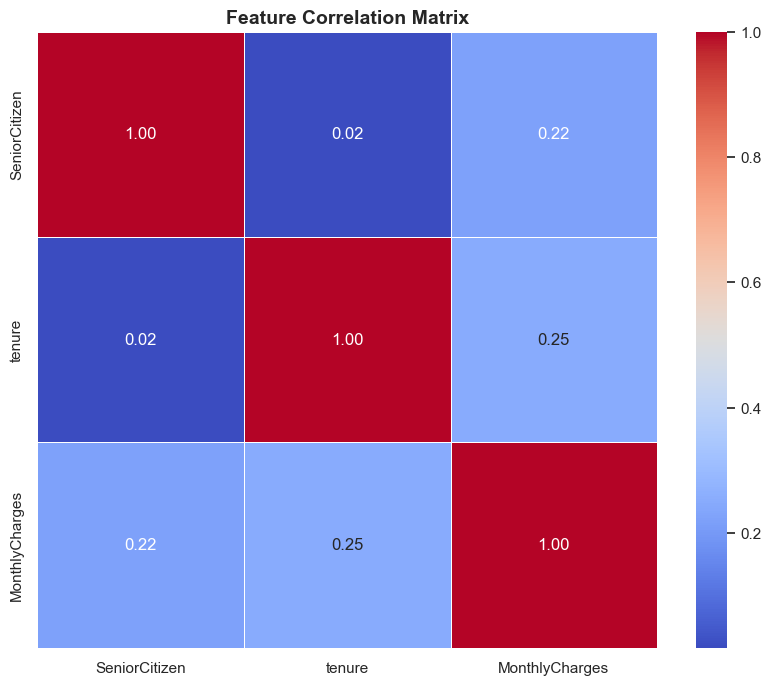

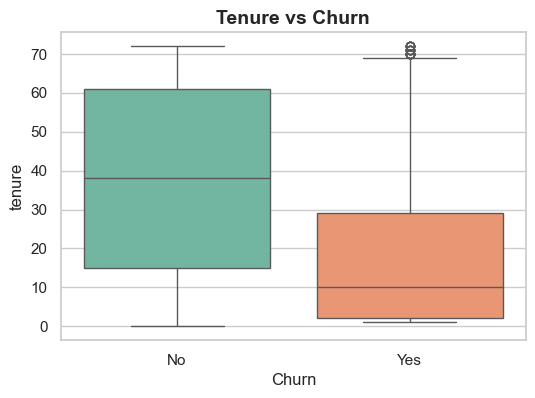

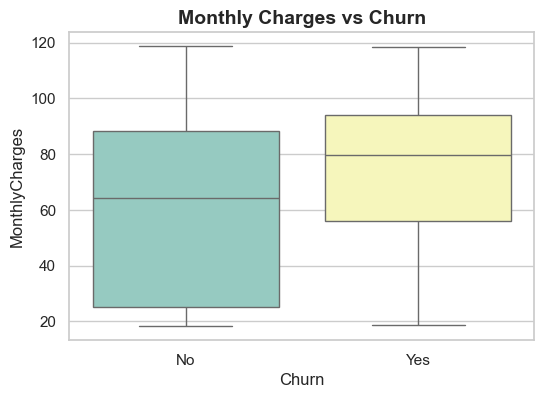

In [126]:
# ============================================================
# SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

"""
Purpose:
--------
- Understand data distribution
- Identify imbalance in target variable
- Detect missing values
- Analyze relationships between features

Why important?
--------------
- Guides feature engineering
- Helps choose correct models
- Prevents garbage-in garbage-out
"""
start_timer("Section 4")

# --------- NUMERICAL SUMMARY ----------
print("📊 Statistical Summary (Numerical Features):")
display(df.describe())


# --------- TARGET VARIABLE DISTRIBUTION ----------
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='coolwarm')

plt.title("Churn Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Churn")
plt.ylabel("Count")

# Add percentage labels
total = len(df)
for p in plt.gca().patches:
    percentage = f"{100 * p.get_height()/total:.1f}%"
    plt.gca().annotate(percentage, 
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom')

plt.show()


# --------- MISSING VALUES ----------
print("\n📌 Missing Values Per Column:")
missing = df.isnull().sum()
display(missing[missing > 0])  # show only columns with missing values


# --------- CORRELATION HEATMAP ----------
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.show()


# --------- ADDITIONAL INSIGHT: TENURE VS CHURN ----------
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')

plt.title("Tenure vs Churn", fontsize=14, fontweight='bold')
plt.show()

# --------- ADDITIONAL INSIGHT: MONTHLY CHARGES VS CHURN ----------
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set3')

plt.title("Monthly Charges vs Churn", fontsize=14, fontweight='bold')
plt.show()

end_timer("Section 4")

In [127]:
# ============================================================
# SECTION 5: DATA CLEANING & TYPE CONVERSION
# ============================================================

"""
Purpose:
--------
- Fix incorrect data types
- Handle missing values safely
- Convert target variable into numeric format
- Remove irrelevant features

Why important?
--------------
- Machine learning models require clean, numeric input
- Prevents errors during training
- Improves model performance and reliability
"""
start_timer("Section 5")
print("🧹 Starting data cleaning process...\n")


# --------- 1. CONVERT 'TotalCharges' TO NUMERIC ----------
"""
Problem:
- 'TotalCharges' is stored as object (string)
- Some entries contain blank spaces → cannot be converted directly

Solution:
- Convert safely using errors='coerce'
- Invalid values become NaN
"""

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing_tc = df['TotalCharges'].isnull().sum()
print(f"📌 Missing values in 'TotalCharges' after conversion: {missing_tc}")


# --------- 2. HANDLE MISSING VALUES ----------
"""
Observation:
- Missing values mostly occur where tenure = 0 (new customers)

Strategy:
- If tenure = 0 → TotalCharges should logically be 0
- Remaining NaN values → fill with median (robust to outliers)
"""

# Set TotalCharges = 0 where tenure = 0
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0

# Fill remaining missing values with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("✅ Missing values handled successfully.")


# --------- 3. ENCODE TARGET VARIABLE ----------
"""
Convert:
- Yes → 1 (customer churned)
- No  → 0 (customer stayed)

This is required for classification models
"""

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("✅ Target variable encoded.")


# --------- 4. REMOVE IRRELEVANT FEATURES ----------
"""
'customerID' is:
- Unique for each customer
- Does not contribute to prediction

Removing it prevents noise in the model
"""

df = df.drop(columns=['customerID'])

print("✅ Irrelevant columns removed.")


# --------- 5. FINAL SANITY CHECK ----------
print("\n📌 Final Data Info After Cleaning:")
df.info()

print("\n✅ Data cleaning completed successfully!\n")

end_timer("Section 5")

🧹 Starting data cleaning process...

📌 Missing values in 'TotalCharges' after conversion: 11
✅ Missing values handled successfully.
✅ Target variable encoded.
✅ Irrelevant columns removed.

📌 Final Data Info After Cleaning:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV      

In [128]:
# ============================================================
# SECTION 6: FEATURE ENGINEERING
# ============================================================

"""
Purpose:
--------
- Create new meaningful features from existing data
- Capture customer behavior patterns
- Improve model predictive performance

Why important?
--------------
- Raw data is often not enough
- Good features = better model performance
"""

start_timer("Section 6")
print("⚙️ Starting feature engineering...\n")


def feature_engineering(df):
    df = df.copy()

    # --------- 1. TENURE-BASED FEATURES ----------
    """
    Insight:
    - Customers staying longer are less likely to churn
    - Short tenure + high charges = high churn risk
    """

    # Avoid division by zero using (tenure + 1)
    df['Tenure_to_Charges'] = df['tenure'] / (df['MonthlyCharges'] + 1)

    # Customer lifecycle stage (categorical grouping)
    df['TenureGroup'] = pd.cut(
        df['tenure'],
        bins=[-1, 12, 24, 48, 72],
        labels=['New', 'Short-Term', 'Mid-Term', 'Long-Term']
    )


    # --------- 2. CUSTOMER VALUE FEATURES ----------
    """
    Insight:
    - High-paying customers behave differently
    """

    df['AvgMonthlyCharge'] = df['TotalCharges'] / (df['tenure'] + 1)

    df['HighSpender'] = (df['MonthlyCharges'] > 80).astype(int)


    # --------- 3. SERVICE USAGE FEATURES ----------
    """
    Insight:
    - Customers using more services are less likely to churn
    """

    df['ServiceCount'] = (
        (df['OnlineSecurity'] == "Yes").astype(int) +
        (df['OnlineBackup'] == "Yes").astype(int) +
        (df['DeviceProtection'] == "Yes").astype(int) +
        (df['TechSupport'] == "Yes").astype(int) +
        (df['StreamingTV'] == "Yes").astype(int) +
        (df['StreamingMovies'] == "Yes").astype(int)
    )

    df['LowEngagement'] = (df['ServiceCount'] <= 2).astype(int)


    # --------- 4. CONTRACT & INTERNET FEATURES ----------
    """
    Insight:
    - Month-to-month users churn more
    - Fiber users often churn due to pricing
    """

    df['IsMonthToMonth'] = (df['Contract'] == "Month-to-month").astype(int)
    df['FiberUser'] = (df['InternetService'] == "Fiber optic").astype(int)

    return df


# --------- APPLY FEATURE ENGINEERING ----------
df = feature_engineering(df)

print("✅ Feature engineering completed successfully!\n")

end_timer("Section 6")

⚙️ Starting feature engineering...

✅ Feature engineering completed successfully!



In [129]:
# ============================================================
# SECTION 7: ENCODING CATEGORICAL VARIABLES
# ============================================================

"""
Purpose:
--------
- Convert categorical variables into numeric format for ML models

Strategy:
---------
1. CatBoost → uses raw categorical features
2. Other models → use One-Hot Encoding
"""
start_timer("Section 7")
print("🔄 Starting encoding process...\n")


# --------- 1. DATA FOR CATBOOST ----------
"""
CatBoost can directly handle categorical variables
So we keep original dataset without encoding
"""

df_for_cat = df.copy()

X_cat = df_for_cat.drop("Churn", axis=1)
y_cat = df_for_cat["Churn"]

# Identify categorical columns
cat_features = X_cat.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"📌 Number of categorical features (CatBoost): {len(cat_features)}")


# --------- 2. ONE-HOT ENCODING FOR OTHER MODELS ----------
"""
Convert categorical variables into binary columns

Example:
Contract → Contract_OneYear, Contract_TwoYear
"""

df_encoded = pd.get_dummies(df, drop_first=True)

print(f"📌 Encoded dataset shape: {df_encoded.shape}")


# --------- 3. SPLIT FEATURES & TARGET ----------
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# --------- CLEAN FEATURE NAMES (REMOVE SPACES) ----------
X.columns = X.columns.str.replace(" ", "_")

print(f"📌 Feature matrix shape: {X.shape}")
print("\n📊 Target distribution:")
print(y.value_counts())


print("\n✅ Encoding completed successfully!\n")

end_timer("Section 7")

🔄 Starting encoding process...

📌 Number of categorical features (CatBoost): 16
📌 Encoded dataset shape: (7043, 41)
📌 Feature matrix shape: (7043, 40)

📊 Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

✅ Encoding completed successfully!



In [130]:
# ============================================================
# SECTION 8: TRAIN-TEST SPLIT & FEATURE SCALING
# ============================================================

"""
Purpose:
--------
- Split dataset into training and testing sets
- Apply feature scaling for models that require it

Why important?
--------------
- Train/Test split ensures fair evaluation
- Scaling improves performance for distance-based and linear models
"""
start_timer("Section 8")
print("🔀 Splitting dataset into train and test sets...\n")


# --------- 1. TRAIN-TEST SPLIT ----------
"""
Strategy:
- 80% training, 20% testing
- Stratified split to maintain churn ratio
"""

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"📌 Training set shape: {X_train.shape}")
print(f"📌 Testing set shape: {X_test.shape}\n")


# --------- 2. FEATURE SCALING ----------
"""
StandardScaler:
- Transforms data to mean = 0, std = 1

Important:
- Fit ONLY on training data
- Transform both train and test data
"""

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed.\n")


# --------- 3. ANN-SPECIFIC SPLIT ----------
"""
For Neural Networks:
- Create validation set from training data
- Used to monitor model performance during training
"""

X_tr_ann, X_val_ann, y_tr_ann, y_val_ann = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE
)

print(f"📌 ANN Training shape: {X_tr_ann.shape}")
print(f"📌 ANN Validation shape: {X_val_ann.shape}\n")


print("🚀 Data preparation (split + scaling) completed successfully!\n")

end_timer("Section 8")

🔀 Splitting dataset into train and test sets...

📌 Training set shape: (5634, 40)
📌 Testing set shape: (1409, 40)

✅ Feature scaling completed.

📌 ANN Training shape: (4507, 40)
📌 ANN Validation shape: (1127, 40)

🚀 Data preparation (split + scaling) completed successfully!



In [131]:
# ============================================================
# SECTION 9: MODEL EVALUATION UTILITIES
# ============================================================

"""
Purpose:
--------
- Provide a standardized way to evaluate all models
- Avoid repeating evaluation code
- Ensure consistent comparison across models

Metrics Used:
-------------
- Accuracy
- Confusion Matrix
- Precision, Recall, F1-score
- ROC-AUC (important for imbalanced data)
"""
start_timer("Section 9")
print("📊 Initializing evaluation utilities...\n")


# --------- UNIVERSAL EVALUATION FUNCTION ----------
def evaluate_model(model, X_te, y_te, model_name="Model", plot_roc=True):
    """
    Evaluates a trained model on test data.

    Parameters:
    -----------
    model : trained model
    X_te  : test features
    y_te  : true labels
    model_name : name for display
    plot_roc : whether to plot ROC curve

    Returns:
    --------
    dict containing performance metrics
    """

    # --------- PREDICTIONS ----------
    y_pred = model.predict(X_te)

    # --------- PROBABILITIES ----------
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
        roc = roc_auc_score(y_te, y_prob)
    else:
        y_prob = None
        roc = None

    acc = accuracy_score(y_te, y_pred)

    # --------- PRINT RESULTS ----------
    print(f"\n{'='*50}")
    print(f"📌 MODEL: {model_name}")
    print(f"{'='*50}")

    print(f"Accuracy: {acc:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_te, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_te, y_pred))

    if roc is not None:
        print(f"ROC-AUC Score: {roc:.4f}")
        pr_auc = average_precision_score(y_te, y_prob)
        print(f"PR-AUC Score: {pr_auc:.4f}")

    # --------- ROC CURVE ----------
    if plot_roc and y_prob is not None:
        fpr, tpr, _ = roc_curve(y_te, y_prob)

        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"AUC = {roc:.3f}")
        plt.plot([0,1], [0,1], linestyle='--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {model_name}")
        plt.legend()
        plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "ROC_AUC": roc,
        "PR_AUC": pr_auc if y_prob is not None else None
    }


print("✅ Evaluation function ready.\n")

end_timer("Section 9")

📊 Initializing evaluation utilities...

✅ Evaluation function ready.



In [132]:
# ============================================================
# CROSS-VALIDATION SETUP (REUSE GLOBAL SKF)
# ============================================================

"""
NOTE:
-----
- StratifiedKFold already defined globally in Section 2
- DO NOT redefine it again to avoid redundancy
"""

print("🔁 Using pre-defined Stratified K-Fold for validation.\n")

🔁 Using pre-defined Stratified K-Fold for validation.



🚀 Training Logistic Regression...

🔁 Performing Stratified Cross-Validation...

📊 Cross-Validated ROC-AUC Scores: [0.8601 0.8448 0.8577 0.8311 0.8404]
📊 Mean ROC-AUC: 0.8468


📌 MODEL: Logistic Regression
Accuracy: 0.7367

Confusion Matrix:
[[744 291]
 [ 80 294]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score: 0.8451
PR-AUC Score: 0.6557


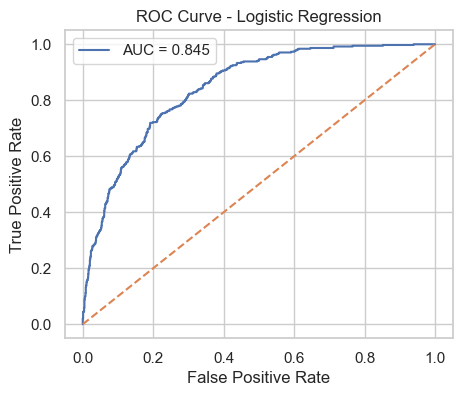

✅ Logistic Regression training completed.



In [133]:
# ============================================================
# SECTION 10: LOGISTIC REGRESSION (BASELINE MODEL)
# ============================================================

"""
Purpose:
--------
- Train a baseline linear model
- Establish a performance benchmark
- Easy to interpret and fast to train

Key Points:
-----------
- Uses StandardScaler (important for linear models)
- Handles class imbalance using class_weight='balanced'
"""
start_timer("Section 10")
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

print("🚀 Training Logistic Regression...\n")


# --------- PIPELINE (SCALING + MODEL) ----------
log_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        n_jobs=-1
    ))
])


# --------- CROSS-VALIDATION ----------
print("🔁 Performing Stratified Cross-Validation...\n")

log_auc_scores = cross_val_score(
    log_pipeline,
    X,
    y,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"📊 Cross-Validated ROC-AUC Scores: {np.round(log_auc_scores, 4)}")
print(f"📊 Mean ROC-AUC: {log_auc_scores.mean():.4f}\n")


# --------- FINAL TRAINING ON FULL TRAIN DATA ----------
log_pipeline.fit(X_train, y_train)


# --------- EVALUATION ----------
log_results = evaluate_model(
    log_pipeline,
    X_test,
    y_test,
    model_name="Logistic Regression"
)

print("✅ Logistic Regression training completed.\n")

end_timer("Section 10")

🌳 Training Decision Tree...

🔁 Performing Stratified Cross-Validation...

📊 Cross-Validated ROC-AUC Scores: [0.839  0.8074 0.8255 0.8022 0.8129]
📊 Mean ROC-AUC: 0.8174


📌 MODEL: Decision Tree
Accuracy: 0.7260

Confusion Matrix:
[[728 307]
 [ 79 295]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1035
           1       0.49      0.79      0.60       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.74      1409

ROC-AUC Score: 0.8279
PR-AUC Score: 0.6305


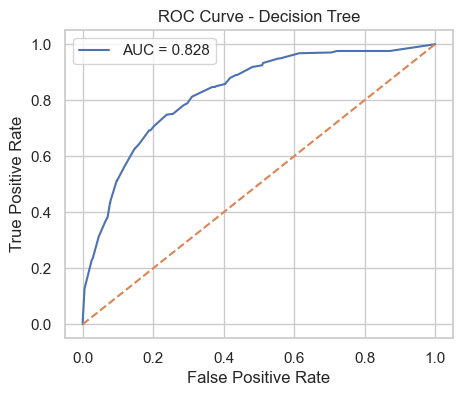

✅ Decision Tree training completed.



In [134]:
# ============================================================
# SECTION 11: DECISION TREE (INTERPRETABLE MODEL)
# ============================================================

"""
Purpose:
--------
- Capture non-linear relationships in data
- Provide interpretable decision rules
- Compare against linear baseline (Logistic Regression)

Key Points:
-----------
- Controlled depth to avoid overfitting
- Handles class imbalance using class_weight='balanced'
"""
start_timer("Section 11")
from sklearn.tree import DecisionTreeClassifier

print("🌳 Training Decision Tree...\n")


# --------- MODEL DEFINITION ----------
dt_model = DecisionTreeClassifier(
    max_depth=6,               # Prevent overfitting
    min_samples_split=10,      # Stable splits
    min_samples_leaf=5,        # Avoid tiny leaf nodes
    class_weight='balanced',
    random_state=RANDOM_STATE
)


# --------- CROSS-VALIDATION ----------
print("🔁 Performing Stratified Cross-Validation...\n")

dt_auc_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"📊 Cross-Validated ROC-AUC Scores: {np.round(dt_auc_scores, 4)}")
print(f"📊 Mean ROC-AUC: {dt_auc_scores.mean():.4f}\n")


# --------- FINAL TRAINING ----------
dt_model.fit(X_train, y_train)


# --------- EVALUATION ----------
dt_results = evaluate_model(
    dt_model,
    X_test,
    y_test,
    model_name="Decision Tree"
)

print("✅ Decision Tree training completed.\n")

end_timer("Section 11")

🌲 Training Random Forest...

🔁 Performing Stratified Cross-Validation...

📊 Cross-Validated ROC-AUC Scores: [0.8533 0.8314 0.8468 0.8242 0.8374]
📊 Mean ROC-AUC: 0.8386

📌 OOB Score: 0.7907


📌 MODEL: Random Forest
Accuracy: 0.7800

Confusion Matrix:
[[865 170]
 [140 234]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1035
           1       0.58      0.63      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.79      0.78      0.78      1409

ROC-AUC Score: 0.8360
PR-AUC Score: 0.6420


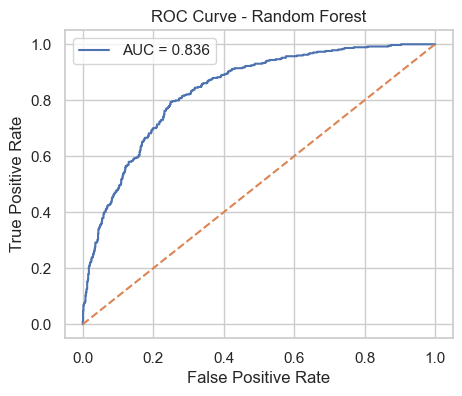

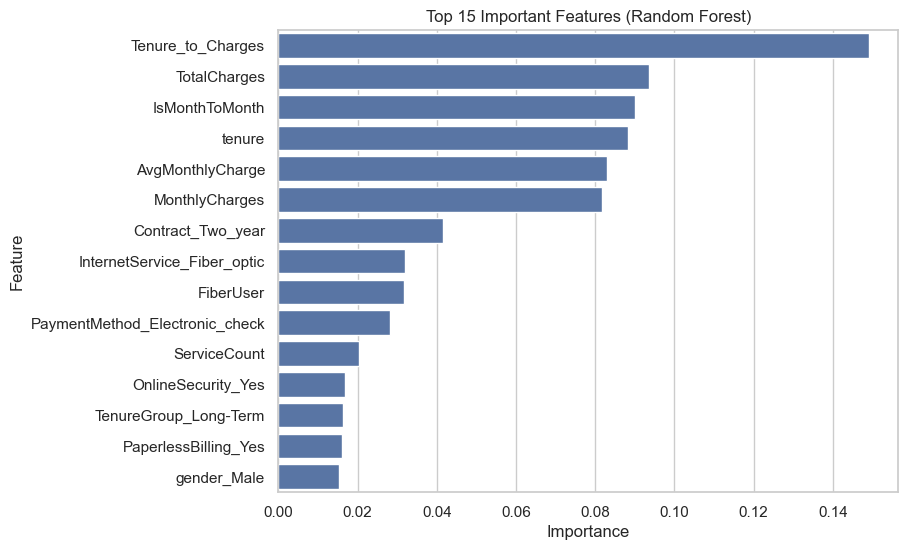

✅ Random Forest training completed.



In [135]:
# ============================================================
# SECTION 12: TUNED RANDOM FOREST
# ============================================================

"""
Purpose:
--------
- Train a robust ensemble model using multiple decision trees
- Reduce overfitting through averaging

Why important?
--------------
- Strong baseline model
- Handles non-linear relationships well
"""
start_timer("Section 12")
from sklearn.ensemble import RandomForestClassifier

print("🌲 Training Random Forest...\n")


# --------- MODEL DEFINITION ----------
rf_weighted = RandomForestClassifier(
    n_estimators=800,          # More trees = more stability
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    oob_score=True,            # Out-of-bag validation
    random_state=RANDOM_STATE,
    n_jobs=-1
)


# --------- CROSS-VALIDATION ----------
print("🔁 Performing Stratified Cross-Validation...\n")

rf_auc_scores = cross_val_score(
    rf_weighted,
    X,
    y,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"📊 Cross-Validated ROC-AUC Scores: {np.round(rf_auc_scores, 4)}")
print(f"📊 Mean ROC-AUC: {rf_auc_scores.mean():.4f}\n")


# --------- FINAL TRAINING ----------
rf_weighted.fit(X_train, y_train)

print(f"📌 OOB Score: {rf_weighted.oob_score_:.4f}\n")


# --------- EVALUATION ----------
rf_results = evaluate_model(
    rf_weighted,
    X_test,
    y_test,
    model_name="Random Forest"
)

# --------- Feature Importance ----------
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_weighted.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(15))
plt.title("Top 15 Important Features (Random Forest)")
plt.show()

print("✅ Random Forest training completed.\n")

end_timer("Section 12")

⚡ Training XGBoost...

📌 Scale Pos Weight: 2.77

🔁 Performing Stratified Cross-Validation...

📊 Cross-Validated ROC-AUC Scores: [0.8527 0.8369 0.8527 0.8261 0.837 ]
📊 Mean ROC-AUC: 0.8411

🎯 Calibrating XGBoost probabilities...

✅ XGBoost calibration completed.


📌 MODEL: XGBoost (Calibrated)
Accuracy: 0.7935

Confusion Matrix:
[[918 117]
 [174 200]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409

ROC-AUC Score: 0.8397
PR-AUC Score: 0.6501


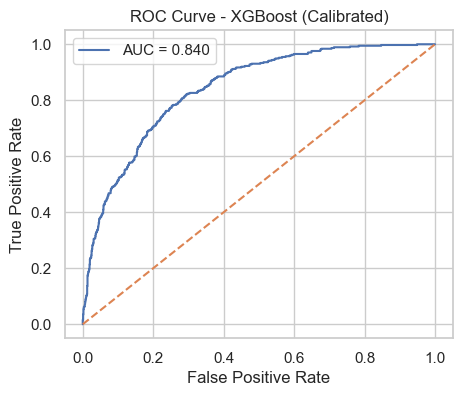

In [136]:
# ============================================================
# SECTION 13: XGBOOST (OPTIMIZED & EFFICIENT)
# ============================================================
start_timer("Section 13")
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV

print("⚡ Training XGBoost...\n")


# --------- CLASS IMBALANCE HANDLING ----------
num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()
scale = num_negative / num_positive

print(f"📌 Scale Pos Weight: {scale:.2f}\n")


# --------- COMMON PARAMETERS ----------
xgb_params = dict(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    reg_alpha=0.2,
    reg_lambda=1.5,
    tree_method="hist",
    eval_metric="auc",
    random_state=RANDOM_STATE,
    n_jobs=-1
)


# --------- CROSS-VALIDATION MODEL ----------
print("🔁 Performing Stratified Cross-Validation...\n")

xgb_cv = XGBClassifier(**xgb_params)

xgb_auc_scores = cross_val_score(
    xgb_cv,
    X,
    y,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"📊 Cross-Validated ROC-AUC Scores: {np.round(xgb_auc_scores, 4)}")
print(f"📊 Mean ROC-AUC: {xgb_auc_scores.mean():.4f}\n")


# --------- TRAIN/VALID SPLIT ----------
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE
)


# --------- MODEL FOR EARLY STOPPING (TUNING ONLY) ----------
xgb_temp = XGBClassifier(
    **xgb_params,
    early_stopping_rounds=50
)

xgb_temp.fit(
    X_train_final,
    y_train_final,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# --------- FINAL MODEL (NO EARLY STOPPING) ----------
base_xgb = XGBClassifier(**xgb_params)

# --------- TRAIN BASE MODEL ----------
base_xgb.fit(
    X_train_final,
    y_train_final,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# --------- PROBABILITY CALIBRATION (CRITICAL FIX) ----------
print("🎯 Calibrating XGBoost probabilities...\n")

xgb_model = CalibratedClassifierCV(
    base_xgb,
    method="sigmoid",
    cv=5
)

xgb_model.fit(X_train, y_train)

print("✅ XGBoost calibration completed.\n")


# --------- EVALUATION (AFTER CALIBRATION) ----------
xgb_results = evaluate_model(
    xgb_model,
    X_test,
    y_test,
    model_name="XGBoost (Calibrated)"
)

end_timer("Section 13")

⚡ Training LightGBM...

📌 Scale Pos Weight: 2.77

🔁 Performing Stratified Cross-Validation...

📊 Cross-Validated ROC-AUC Scores: [0.8413 0.8285 0.8442 0.8203 0.8304]
📊 Mean ROC-AUC: 0.8329

[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003398 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1168
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265365 -> initscore=-1.018268
[LightGBM] [Info] Start training from score -1.018268
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002875 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1168
[LightGBM] [Info] Number of data points in the train s

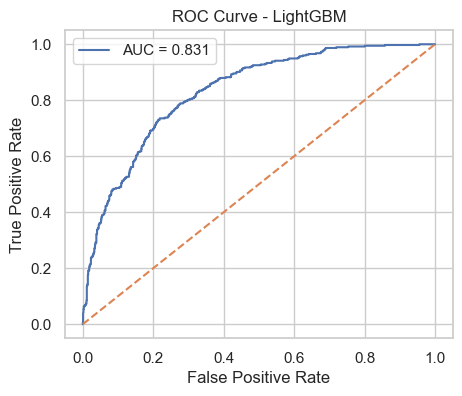

✅ LightGBM training completed.



In [137]:
# ============================================================
# SECTION 14: LIGHTGBM (PRIMARY BOOSTING MODEL)
# ============================================================

"""
Purpose:
--------
- Train a fast and powerful gradient boosting model
- Capture complex feature interactions efficiently

Why LightGBM?
-------------
- Faster than XGBoost
- Handles large datasets efficiently
- Performs very well on tabular data
"""
start_timer("Section 14")
from lightgbm import LGBMClassifier

print("⚡ Training LightGBM...\n")


# --------- CLASS IMBALANCE HANDLING ----------
num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()
scale = num_negative / num_positive

print(f"📌 Scale Pos Weight: {scale:.2f}\n")


# --------- MODEL DEFINITION ----------
lgb_model = LGBMClassifier(
    n_estimators=400,          # Reduced from 800 → faster
    learning_rate=0.05,        # Slightly higher → faster convergence
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=RANDOM_STATE,
    n_jobs=-1
)


# --------- CROSS-VALIDATION ----------
print("🔁 Performing Stratified Cross-Validation...\n")

lgb_auc_scores = cross_val_score(
    lgb_model,
    X,
    y,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"📊 Cross-Validated ROC-AUC Scores: {np.round(lgb_auc_scores, 4)}")
print(f"📊 Mean ROC-AUC: {lgb_auc_scores.mean():.4f}\n")

# --------- TRAIN/VALID SPLIT (IMPORTANT) ----------
X_train_lgb, X_val_lgb, y_train_lgb, y_val_lgb = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE
)

# --------- FINAL TRAINING WITH EARLY STOPPING ----------
lgb_model.fit(
    X_train_lgb,
    y_train_lgb,
    eval_set=[(X_val_lgb, y_val_lgb)],
    eval_metric='auc',
)

# Note: LightGBM uses early stopping via callbacks if needed
# (keeping simple for stability across versions)


# --------- RETRAIN ON FULL DATA (CRITICAL FIX) ----------
# Use same parameters but train on full dataset

lgb_model_full = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lgb_model_full.fit(X_train, y_train)

# Replace model with full-data trained version
lgb_model = lgb_model_full


# --------- EVALUATION ----------
lgb_results = evaluate_model(
    lgb_model,
    X_test,
    y_test,
    model_name="LightGBM"
)

print("✅ LightGBM training completed.\n")

end_timer("Section 14")

🚀 Training CatBoost...

📌 Class Weights: [1, np.float64(2.768561872909699)]

🔁 Performing Stratified Cross-Validation...

📊 Cross-Validated ROC-AUC Scores: [0.8559 0.8394 0.8539 0.8313 0.8348]
📊 Mean ROC-AUC: 0.8430


📌 MODEL: CatBoost
Accuracy: 0.7488

Confusion Matrix:
[[758 277]
 [ 77 297]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC Score: 0.8433
PR-AUC Score: 0.6604


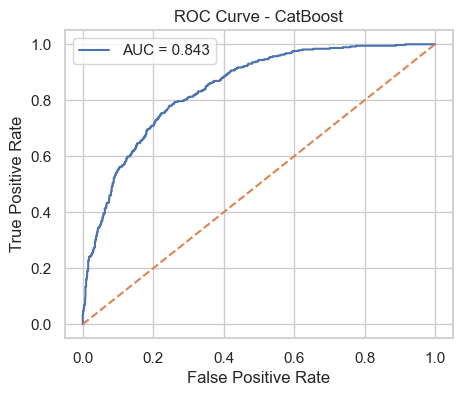

✅ CatBoost training completed.



In [138]:
# ============================================================
# SECTION 15: CATBOOST (CATEGORICAL BOOSTING MODEL)
# ============================================================

"""
Purpose:
--------
- Train a powerful boosting model that handles categorical data natively
- Avoids need for one-hot encoding

Why CatBoost?
-------------
- Handles categorical variables automatically
- Reduces preprocessing effort
- Often performs very well on tabular data
"""
start_timer("Section 15")
from catboost import CatBoostClassifier

print("🚀 Training CatBoost...\n")


# --------- CLEAN CATEGORICAL DATA ----------
for col in cat_features:
    X_cat[col] = X_cat[col].astype(str).fillna("Missing")


# --------- CLASS WEIGHTS ----------
num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()
class_weights = [1, num_negative / num_positive]

print(f"📌 Class Weights: {class_weights}\n")


# --------- MODEL DEFINITION ----------
cat_params = dict(
    iterations=500,              # Reduced from 2000 → faster
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    eval_metric="AUC",
    task_type="GPU" if torch.cuda.is_available() else "CPU",             # Uses your RTX 4060
    class_weights=class_weights,
    random_seed=RANDOM_STATE,
    verbose=False
)


# --------- CROSS-VALIDATION ----------
from sklearn.metrics import roc_auc_score

print("🔁 Performing Stratified Cross-Validation...\n")

cat_auc_scores = []

for train_idx, val_idx in skf.split(X_cat, y_cat):
    X_train_fold = X_cat.iloc[train_idx]
    X_val_fold = X_cat.iloc[val_idx]
    y_train_fold = y_cat.iloc[train_idx]
    y_val_fold = y_cat.iloc[val_idx]

    model = CatBoostClassifier(**cat_params)

    model.fit(
        X_train_fold,
        y_train_fold,
        cat_features=cat_features,
        verbose=False
    )

    preds = model.predict_proba(X_val_fold)[:, 1]
    auc = roc_auc_score(y_val_fold, preds)
    cat_auc_scores.append(auc)

cat_auc_scores = np.array(cat_auc_scores)

print(f"📊 Cross-Validated ROC-AUC Scores: {np.round(cat_auc_scores, 4)}")
print(f"📊 Mean ROC-AUC: {cat_auc_scores.mean():.4f}\n")


# --------- FINAL TRAINING WITH EARLY STOPPING ----------
from sklearn.model_selection import train_test_split

# --------- TRAIN/VALID SPLIT ----------
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_cat.loc[X_train.index],
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE
)


# --------- FINAL MODEL ----------
cat_model = CatBoostClassifier(**cat_params)


# --------- TRAIN ----------
cat_model.fit(
    X_train_final,
    y_train_final,
    cat_features=cat_features,
    eval_set=(X_val, y_val),   # ✅ correct
    early_stopping_rounds=50,
    verbose=False
)


# --------- EVALUATION ----------
cat_results = evaluate_model(
    cat_model,
    X_cat.loc[X_test.index],
    y_test,
    model_name="CatBoost"
)

print("✅ CatBoost training completed.\n")

end_timer("Section 15")

🚀 Training Stacking Model...

🔁 Performing Stratified Cross-Validation...

📊 Cross-Validated ROC-AUC Scores: [0.8624 0.8449 0.8592 0.8319 0.8429]
📊 Mean ROC-AUC: 0.8483


📌 MODEL: Stacked Model
Accuracy: 0.7537

Confusion Matrix:
[[766 269]
 [ 78 296]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409

ROC-AUC Score: 0.8465
PR-AUC Score: 0.6610


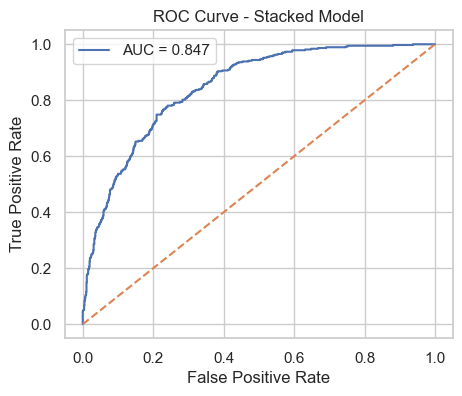

✅ Stacking model training completed.



In [139]:
# ============================================================
# SECTION 16: STACKING (FINAL ENSEMBLE MODEL)
# ============================================================

"""
Purpose:
--------
- Combine multiple models to improve performance
- Leverage strengths of different algorithms

How it works:
-------------
- Base models make predictions
- Meta-model learns how to combine them

Models Used:
------------
- Random Forest → stable & robust
- Logistic Regression → linear baseline
- LightGBM → powerful boosting model
"""
start_timer("Section 16")
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

print("🚀 Training Stacking Model...\n")


# --------- BASE MODELS ----------
estimators = [
    ('rf', rf_weighted),
    ('log', make_pipeline(
        StandardScaler(),
        LogisticRegression(
            class_weight='balanced',
            max_iter=1000
        )
    )),
    ('lgb', lgb_model)
]


# --------- META-LEARNER ----------
final_estimator = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)


# --------- STACKING MODEL ----------
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    passthrough=False,
    n_jobs=-1
)


# --------- CROSS-VALIDATION ----------
print("🔁 Performing Stratified Cross-Validation...\n")

stack_auc_scores = cross_val_score(
    stack_model,
    X,
    y,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"📊 Cross-Validated ROC-AUC Scores: {np.round(stack_auc_scores, 4)}")
print(f"📊 Mean ROC-AUC: {stack_auc_scores.mean():.4f}\n")


# --------- FINAL TRAINING ----------
stack_model.fit(X_train, y_train)


# --------- EVALUATION ----------
stack_results = evaluate_model(
    stack_model,
    X_test,
    y_test,
    model_name="Stacked Model"
)

print("✅ Stacking model training completed.\n")

end_timer("Section 16")

📊 Generating model comparison...

🏆 FINAL MODEL COMPARISON TABLE:


,Model,Accuracy,ROC_AUC,PR_AUC
0,Stacked Model,0.753726,0.846545,0.660999
1,Logistic Regression,0.736693,0.845083,0.655740
2,CatBoost,0.748758,0.843287,0.660428
3,XGBoost (Calibrated),0.793471,0.839664,0.650099
4,Random Forest,0.779986,0.835986,0.641984
5,LightGBM,0.772179,0.831178,0.634071
6,Decision Tree,0.726047,0.827942,0.630533


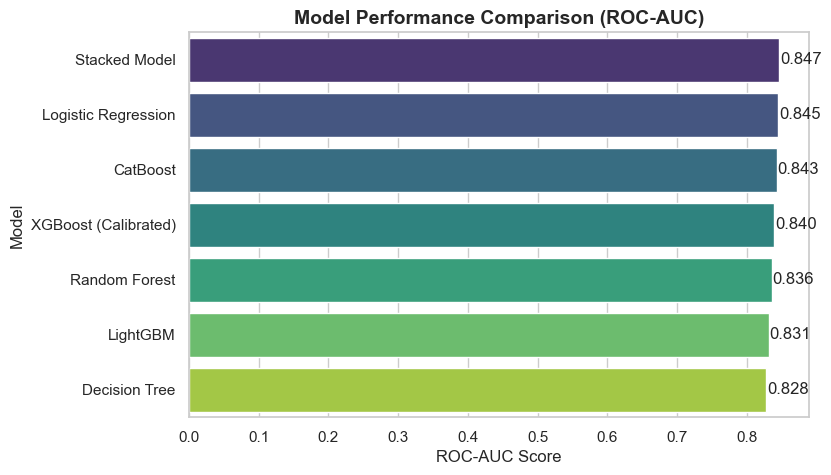

✅ Model comparison completed.



In [140]:
# ============================================================
# SECTION 17: MODEL COMPARISON & VISUALIZATION
# ============================================================

"""
Purpose:
--------
- Compare performance of all trained models
- Identify the best performing model based on ROC-AUC

Why important?
--------------
- Helps select final model
- Provides clear comparison for analysis and presentation
"""
start_timer("Section 17")

print("📊 Generating model comparison...\n")


# --------- COLLECT MODEL RESULTS ----------
model_results = [
    log_results,
    dt_results,
    rf_results,
    xgb_results,
    lgb_results,
    cat_results,
    stack_results
]

# Convert to DataFrame
results_df = pd.DataFrame(model_results)

# Sort by ROC-AUC (best model on top)
results_df = results_df.sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)


# --------- DISPLAY TABLE ----------
print("🏆 FINAL MODEL COMPARISON TABLE:")
display(results_df)


# --------- VISUALIZATION ----------
plt.figure(figsize=(8,5))

sns.barplot(
    x="ROC_AUC",
    y="Model",
    data=results_df,
    palette="viridis"
)

plt.title("Model Performance Comparison (ROC-AUC)", fontsize=14, fontweight='bold')
plt.xlabel("ROC-AUC Score")
plt.ylabel("Model")

# Add value labels
for i, v in enumerate(results_df["ROC_AUC"]):
    plt.text(v + 0.001, i, f"{v:.3f}", va='center')

plt.show()


print("✅ Model comparison completed.\n")

end_timer("Section 17")

🎯 Performing threshold optimization...

📊 Threshold Performance Table:


,Threshold,Precision,Recall,Cost
0,0.10,0.339779,0.986631,408500
1,0.15,0.369060,0.975936,402000
2,0.20,0.390879,0.962567,420500
3,0.25,0.407666,0.938503,485000
4,0.30,0.434080,0.933155,477500
5,0.35,0.449602,0.906417,557500
6,0.40,0.465517,0.866310,686000
7,0.45,0.489666,0.823529,820500
8,0.50,0.502564,0.786096,945500
9,0.55,0.538168,0.754011,1041000


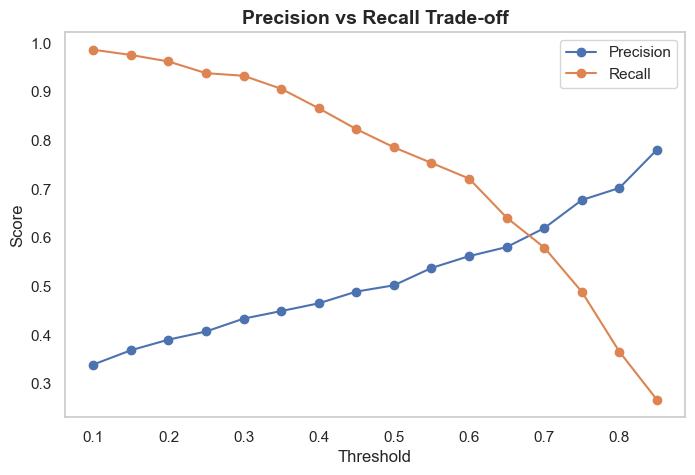


🏆 Best Threshold (Min Cost): 0.15
Precision: 0.3691
Recall: 0.9759
Cost: ₹402,000.0


In [141]:
# ============================================================
# SECTION 18: THRESHOLD OPTIMIZATION (LOGISTIC REGRESSION)
# ============================================================

"""
Purpose:
--------
- Find the optimal probability threshold for classification
- Improve recall (catch more churners) while balancing precision

Why important?
--------------
- Default threshold = 0.5 may not be optimal
- Business may prefer higher recall (catch churners early)
"""
start_timer("Section 18")
print("🎯 Performing threshold optimization...\n")


# --------- USE TRAINED MODEL ----------
# Use pipeline (handles scaling internally)
y_prob_log = log_pipeline.predict_proba(X_test)[:, 1]


# --------- COST FUNCTION ----------
def calculate_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * 10000 + fp * 500


# --------- TEST DIFFERENT THRESHOLDS ----------
thresholds = np.arange(0.1, 0.9, 0.05)

results_threshold = []

for t in thresholds:
    y_pred_thresh = (y_prob_log >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    cost = calculate_cost(y_test, y_pred_thresh)
    
    results_threshold.append({
        "Threshold": t,
        "Precision": precision,
        "Recall": recall,
        "Cost": cost
    })


# --------- CREATE DATAFRAME ----------
threshold_df = pd.DataFrame(results_threshold)

print("📊 Threshold Performance Table:")
display(threshold_df)


# --------- VISUALIZATION ----------
plt.figure(figsize=(8,5))

plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision", marker='o')
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall", marker='o')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall Trade-off", fontsize=14, fontweight='bold')
plt.legend()
plt.grid()

plt.show()


# --------- FIND BEST THRESHOLD ----------
# Example: maximize recall while keeping precision reasonable

best_row = threshold_df.loc[threshold_df["Cost"].idxmin()]

print(f"\n🏆 Best Threshold (Min Cost): {best_row['Threshold']:.2f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"Cost: ₹{best_row['Cost']:,}")

end_timer("Section 18")

In [142]:
# ============================================================
# SECTION 19: STRATIFIED CROSS-VALIDATION (FINAL CHECK)
# ============================================================

"""
Purpose:
--------
- Validate model performance using multiple data splits
- Ensure model generalizes well

Why important?
--------------
- Reduces overfitting risk
- Provides reliable performance estimate
"""
start_timer("Section 19")

print("🔁 Performing final cross-validation check...\n")


# --------- CROSS-VALIDATION ----------
cv_scores = cross_val_score(
    log_pipeline,   # use pipeline (includes scaling)
    X,
    y,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"📊 Cross-Validation ROC-AUC Scores: {np.round(cv_scores, 4)}")
print(f"📊 Mean ROC-AUC: {cv_scores.mean():.4f}\n")

end_timer("Section 19")

🔁 Performing final cross-validation check...

📊 Cross-Validation ROC-AUC Scores: [0.8601 0.8448 0.8577 0.8311 0.8404]
📊 Mean ROC-AUC: 0.8468



In [143]:
# ============================================================
# SECTION 20: HYPERPARAMETER TUNING USING OPTUNA
# ============================================================

"""
Purpose:
--------
- Automatically find best hyperparameters for Logistic Regression

Why important?
--------------
- Improves model performance without manual trial-and-error
"""
start_timer("Section 20")

import optuna

print("⚙️ Starting hyperparameter tuning with Optuna...\n")


# --------- OBJECTIVE FUNCTION ----------
def objective(trial):
    
    C = trial.suggest_float("C", 1e-4, 10, log=True)
    
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=C,
            solver="lbfgs",
            class_weight='balanced',   # IMPORTANT
            max_iter=1000
        ))
    ])
    
    score = cross_val_score(
        pipeline,
        X,
        y,
        cv=skf,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()
    
    return score


# --------- RUN OPTUNA ----------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)


# --------- RESULTS ----------
print("🏆 Best Parameters:", study.best_params)
print(f"🏆 Best ROC-AUC: {study.best_value:.4f}\n")

end_timer("Section 20")

[I 2026-03-30 23:22:08,015] A new study created in memory with name: no-name-c740b12e-0589-4d5b-9024-59f5354b4b2d


⚙️ Starting hyperparameter tuning with Optuna...



[I 2026-03-30 23:22:16,155] Trial 0 finished with value: 0.8468386271786809 and parameters: {'C': 0.7828823896110311}. Best is trial 0 with value: 0.8468386271786809.
[I 2026-03-30 23:22:25,630] Trial 1 finished with value: 0.8459341585909099 and parameters: {'C': 0.007741467457244091}. Best is trial 0 with value: 0.8468386271786809.
[I 2026-03-30 23:22:25,765] Trial 2 finished with value: 0.8450759299538246 and parameters: {'C': 0.0025356269257134014}. Best is trial 0 with value: 0.8468386271786809.
[I 2026-03-30 23:22:25,885] Trial 3 finished with value: 0.8467797954891093 and parameters: {'C': 0.05781032783077133}. Best is trial 0 with value: 0.8468386271786809.
[I 2026-03-30 23:22:26,011] Trial 4 finished with value: 0.8468538781533235 and parameters: {'C': 0.0927047838698282}. Best is trial 4 with value: 0.8468538781533235.
[I 2026-03-30 23:22:26,119] Trial 5 finished with value: 0.8418116767422456 and parameters: {'C': 0.0006070990573504764}. Best is trial 4 with value: 0.8468538

🏆 Best Parameters: {'C': 0.62620241788144}
🏆 Best ROC-AUC: 0.8469



🚀 Training final tuned Logistic Regression...


📌 MODEL: Tuned Logistic Regression
Accuracy: 0.7388

Confusion Matrix:
[[748 287]
 [ 81 293]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score: 0.8454
PR-AUC Score: 0.6561


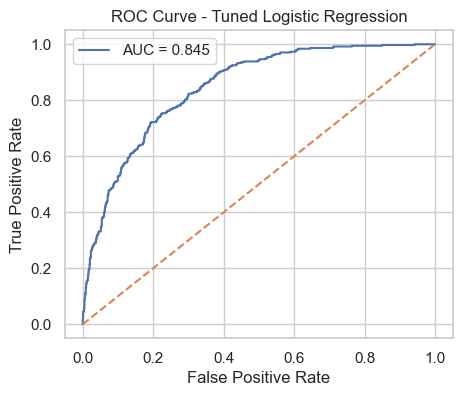

✅ Final tuned model ready.



In [144]:
# ============================================================
# SECTION 21: FINAL TUNED LOGISTIC REGRESSION
# ============================================================

"""
Purpose:
--------
- Train final optimized Logistic Regression model using best parameters
- Serve as interpretable and efficient final model

Why important?
--------------
- Combines tuning + proper preprocessing
- Ready for deployment or business use
"""

start_timer("Section 21")

print("🚀 Training final tuned Logistic Regression...\n")


# --------- GET BEST PARAMETERS ----------
best_params = study.best_params


# --------- FINAL PIPELINE ----------
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=best_params["C"],
        solver="lbfgs",
        class_weight="balanced",
        max_iter=1000
    ))
])


# --------- TRAIN ----------
final_pipeline.fit(X_train, y_train)


# --------- EVALUATE ----------
final_result = evaluate_model(
    final_pipeline,
    X_test,
    y_test,
    model_name="Tuned Logistic Regression"
)

print("✅ Final tuned model ready.\n")

end_timer("Section 21")

🎯 Optimizing threshold for tuned model...

📊 Threshold Performance Table:


,Threshold,Precision,Recall
0,0.10,0.339154,0.986631
1,0.15,0.368049,0.973262
2,0.20,0.390642,0.959893
3,0.25,0.406721,0.938503
4,0.30,0.433915,0.930481
5,0.35,0.450199,0.906417
6,0.40,0.466187,0.866310
7,0.45,0.490476,0.826203
8,0.50,0.505172,0.783422
9,0.55,0.539197,0.754011


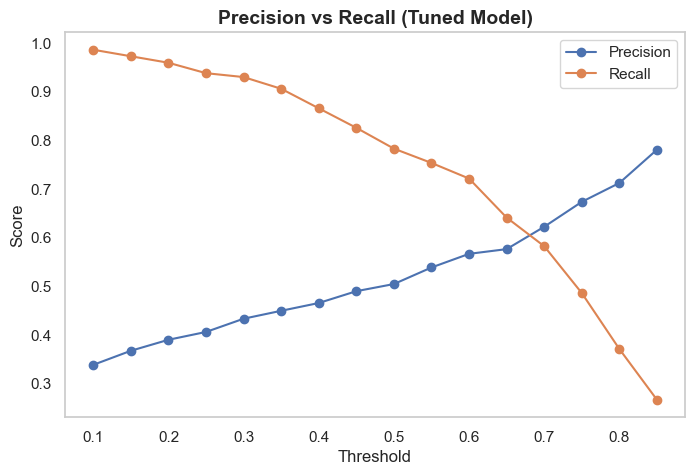


🏆 Best Threshold (Max Recall): 0.10
Precision: 0.3392
Recall: 0.9866


In [145]:
# ============================================================
# SECTION 22: THRESHOLD OPTIMIZATION (TUNED MODEL)
# ============================================================

"""
Purpose:
--------
- Optimize classification threshold for tuned model
- Balance precision and recall based on business needs
"""

start_timer("Section 22")

print("🎯 Optimizing threshold for tuned model...\n")


# --------- PROBABILITIES ----------
y_prob_tuned = final_pipeline.predict_proba(X_test)[:, 1]


# --------- THRESHOLD TESTING ----------
thresholds = np.arange(0.1, 0.9, 0.05)
results_threshold_tuned = []

for t in thresholds:
    y_pred_thresh = (y_prob_tuned >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    
    results_threshold_tuned.append({
        "Threshold": t,
        "Precision": precision,
        "Recall": recall
    })


# --------- DATAFRAME ----------
threshold_df_tuned = pd.DataFrame(results_threshold_tuned)

print("📊 Threshold Performance Table:")
display(threshold_df_tuned)


# --------- VISUALIZATION ----------
plt.figure(figsize=(8,5))

plt.plot(threshold_df_tuned["Threshold"], threshold_df_tuned["Precision"], label="Precision", marker='o')
plt.plot(threshold_df_tuned["Threshold"], threshold_df_tuned["Recall"], label="Recall", marker='o')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall (Tuned Model)", fontsize=14, fontweight='bold')
plt.legend()
plt.grid()

plt.show()


# --------- BEST THRESHOLD ----------
best_row = threshold_df_tuned.loc[threshold_df_tuned["Recall"].idxmax()]

print(f"\n🏆 Best Threshold (Max Recall): {best_row['Threshold']:.2f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")

end_timer("Section 22")

🔍 Generating SHAP explanations...



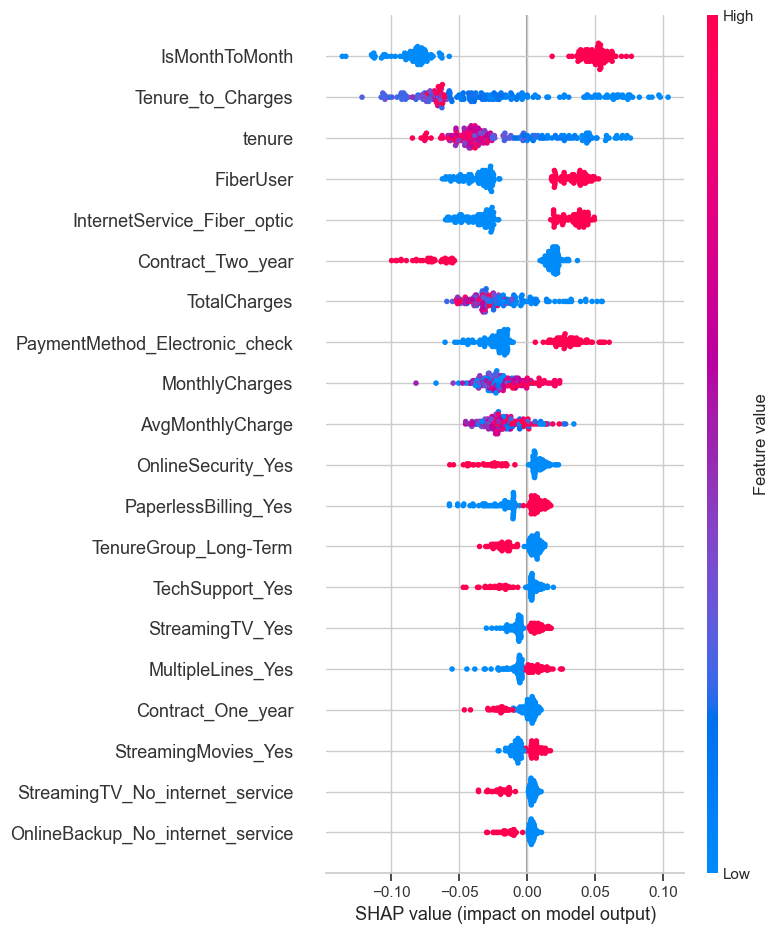

✅ SHAP explainability completed.



In [146]:
# ============================================================
# SECTION 23: SHAP EXPLAINABILITY
# ============================================================

"""
Purpose:
--------
- Explain model predictions
- Identify which features influence churn decisions

Why important?
--------------
- Makes model interpretable
- Helps business understand key drivers of churn
"""

start_timer("Section 23")

import shap

print("🔍 Generating SHAP explanations...\n")


# --------- SAMPLE DATA (FOR SPEED) ----------
X_test_sample = X_test.sample(200, random_state=RANDOM_STATE)


# --------- CREATE EXPLAINER ----------
explainer = shap.TreeExplainer(rf_weighted)


# --------- COMPUTE SHAP VALUES ----------
shap_values = explainer(X_test_sample)


# --------- HANDLE SHAP OUTPUT (ROBUST) ----------
if len(shap_values.values.shape) == 3:
    # For binary classification → take class 1
    shap_values_to_plot = shap_values.values[:, :, 1]
else:
    shap_values_to_plot = shap_values.values


# --------- SUMMARY PLOT ----------
shap.summary_plot(
    shap_values_to_plot,
    X_test_sample,
    feature_names=X.columns
)


print("✅ SHAP explainability completed.\n")

end_timer("Section 23")

In [147]:
# ============================================================
# SECTION 24: ARTIFICIAL NEURAL NETWORK (ANN)
# ============================================================

"""
Purpose:
--------
- Train a deep learning model to capture complex patterns
- Compare performance with traditional ML models
"""

start_timer("Section 24")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("🤖 Training ANN...\n")


# --------- DEVICE ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --------- SET RANDOM SEED ----------
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    
# --------- TENSORS ----------
# ✅ Use proper train/validation split (NO DATA LEAKAGE)

X_tr_tensor = torch.tensor(X_tr_ann, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_tr_ann.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_ann, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_ann.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)


# --------- DATALOADER ----------
train_loader = DataLoader(
    TensorDataset(X_tr_tensor, y_tr_tensor),
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=64,
    shuffle=False
)


# --------- MODEL ----------
class ImprovedANN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)


model = ImprovedANN(X_tr_ann.shape[1]).to(device)


# --------- CLASS IMBALANCE ----------
pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.0005)


# --------- TRAINING ----------
epochs = 40

# ✅ Early Stopping Setup
best_val_loss = float("inf")
patience = 5
counter = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for xb, yb in train_loader:
        # ✅ Move batch to GPU (efficient)
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb).view(-1)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # --------- VALIDATION ----------
    model.eval()
    with torch.no_grad():
        val_loss = 0
        for xb_val, yb_val in val_loader:
            xb_val, yb_val = xb_val.to(device), yb_val.to(device)
            
            val_outputs = model(xb_val).view(-1)
            loss = criterion(val_outputs, yb_val)
            val_loss += loss.item()
        
        val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {total_loss/len(train_loader):.4f}, Val Loss: {val_loss:.4f}")

    # --------- EARLY STOPPING ----------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

print("✅ ANN training completed.\n")

end_timer("Section 24")

🤖 Training ANN...

Using device: cpu
Epoch 1/40, Train Loss: 0.8231, Val Loss: 0.7405
Epoch 2/40, Train Loss: 0.7585, Val Loss: 0.7203
Epoch 3/40, Train Loss: 0.7402, Val Loss: 0.7147
Epoch 4/40, Train Loss: 0.7226, Val Loss: 0.7144
Epoch 5/40, Train Loss: 0.7251, Val Loss: 0.7118
Epoch 6/40, Train Loss: 0.7192, Val Loss: 0.7142
Epoch 7/40, Train Loss: 0.7180, Val Loss: 0.7138
Epoch 8/40, Train Loss: 0.7037, Val Loss: 0.7095
Epoch 9/40, Train Loss: 0.7139, Val Loss: 0.7120
Epoch 10/40, Train Loss: 0.7105, Val Loss: 0.7107
Epoch 11/40, Train Loss: 0.7100, Val Loss: 0.7108
Epoch 12/40, Train Loss: 0.7052, Val Loss: 0.7107
Epoch 13/40, Train Loss: 0.7000, Val Loss: 0.7128
⛔ Early stopping triggered
✅ ANN training completed.



In [148]:
# ============================================================
# SECTION 25: ANN EVALUATION
# ============================================================

start_timer("Section 25")

print("📊 Evaluating ANN...\n")

model.eval()

with torch.no_grad():
    logits = model(X_test_tensor.to(device)).squeeze()
    probs_ann = torch.sigmoid(logits).cpu().numpy()

roc_ann = roc_auc_score(y_test, probs_ann)

preds = (probs_ann >= 0.5).astype(int)
acc_ann = accuracy_score(y_test, preds)

print(f"ANN ROC-AUC: {roc_ann:.4f}")
print(f"ANN Accuracy @0.5: {acc_ann:.4f}\n")

end_timer("Section 25")

📊 Evaluating ANN...

ANN ROC-AUC: 0.8450
ANN Accuracy @0.5: 0.7211



In [149]:
# ============================================================
# SECTION 26: FINAL MODEL SUMMARY
# ============================================================

start_timer("Section 26")

"""
Purpose:
--------
- Summarize performance of all models
- Compare final results including ANN
"""

print("🏁 Generating final model summary...\n")

# --------- COLLECT RESULTS ----------
final_results = [
    log_results,
    dt_results,
    rf_results,
    xgb_results,
    lgb_results,
    cat_results,
    stack_results,
    final_result,   # tuned logistic
    {
        "Model": "ANN",
        "Accuracy": acc_ann,
        "ROC_AUC": roc_ann
    }
]

# --------- CREATE TABLE ----------
final_df = pd.DataFrame(final_results)

def calculate_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * 10000 + fp * 500

model_costs = []
model_thresholds = {}

for model_name in final_df["Model"]:
    
    if model_name == "Logistic Regression":
        probs = log_pipeline.predict_proba(X_test)[:, 1]
        
    elif model_name == "Tuned Logistic Regression":
        probs = final_pipeline.predict_proba(X_test)[:, 1]
        
    elif model_name == "Random Forest":
        probs = rf_weighted.predict_proba(X_test)[:, 1]
        
    elif "XGBoost" in model_name:
        probs = xgb_model.predict_proba(X_test)[:, 1]
        
    elif model_name == "LightGBM":
        probs = lgb_model.predict_proba(X_test)[:, 1]
        
    elif model_name == "CatBoost":
        probs = cat_model.predict_proba(X_cat.loc[X_test.index])[:, 1]
        
    elif model_name == "Stacked Model":
        probs = stack_model.predict_proba(X_test)[:, 1]
        
    elif model_name == "ANN":
        probs = probs_ann   # ANN probabilities
        
    else:
        probs = None

    if probs is not None:
        thresholds = np.linspace(0.01, 0.99, 50)

        best_cost = float("inf")
        best_threshold_model = 0.5  # default fallback

        for t in thresholds:
            preds = (probs >= t).astype(int)
            cost = calculate_cost(y_test, preds)
            
            if cost < best_cost:
                best_cost = cost
                best_threshold_model = t

        # --------- STANDARDIZE MODEL NAME ----------
        if "XGBoost" in model_name:
            key = "XGBoost"
        elif "Random Forest" in model_name:
            key = "Random Forest"
        elif "LightGBM" in model_name:
            key = "LightGBM"
        elif "CatBoost" in model_name:
            key = "CatBoost"
        elif "Stacked Model" in model_name:
            key = "Stacked Model"
        elif "Tuned Logistic Regression" in model_name:
            key = "Tuned Logistic Regression"
        elif "Logistic Regression" in model_name:
            key = "Logistic Regression"
        elif "ANN" in model_name:
            key = "ANN"
        else:
            key = model_name

        model_thresholds[key] = best_threshold_model
        cost = best_cost
    else:
        cost = None

    model_costs.append(cost)

final_df["Cost"] = model_costs

# --------- SORT BY BUSINESS VALUE ----------
final_df = final_df.sort_values(by="Cost").reset_index(drop=True)

# --------- DISPLAY ----------
print("\n📊 FULL MODEL COMPARISON:")
print(final_df)

# --------- EXCLUDE ANN FROM FINAL SELECTION ----------
final_df_no_ann = final_df[final_df["Model"] != "ANN"]

best_model = final_df_no_ann.iloc[0]

print("\n🏆 BEST MODEL (BUSINESS OPTIMAL):")
print(best_model)

# ============================================================
# FINAL MODEL SELECTION (SINGLE SOURCE OF TRUTH)
# ============================================================

if "XGBoost" in best_model["Model"]:
    final_model = xgb_model
elif "Random Forest" in best_model["Model"]:
    final_model = rf_weighted
elif "LightGBM" in best_model["Model"]:
    final_model = lgb_model
elif "CatBoost" in best_model["Model"]:
    final_model = cat_model
elif "Stacked Model" in best_model["Model"]:
    final_model = stack_model
elif "Tuned Logistic Regression" in best_model["Model"]:
    final_model = final_pipeline
elif "Logistic Regression" in best_model["Model"]:
    final_model = log_pipeline
else:
    raise ValueError(f"❌ Unknown model selected: {best_model['Model']}")

print(f"✅ Final model selected: {best_model['Model']}")

# ============================================================
# FINAL THRESHOLD SELECTION
# ============================================================

final_model_name = best_model["Model"]

if "XGBoost" in final_model_name:
    final_threshold = model_thresholds["XGBoost"]
elif "Random Forest" in final_model_name:
    final_threshold = model_thresholds["Random Forest"]
elif "LightGBM" in final_model_name:
    final_threshold = model_thresholds["LightGBM"]
elif "CatBoost" in final_model_name:
    final_threshold = model_thresholds["CatBoost"]
elif "Stacked Model" in final_model_name:
    final_threshold = model_thresholds["Stacked Model"]
elif "Tuned Logistic Regression" in final_model_name:
    final_threshold = model_thresholds["Tuned Logistic Regression"]
elif "Logistic Regression" in final_model_name:
    final_threshold = model_thresholds["Logistic Regression"]
else:
    raise ValueError(f"❌ Threshold not found for model: {final_model_name}")

print(f"🎯 Final threshold (cost-optimal): {final_threshold:.2f}")

end_timer("Section 26")

🏁 Generating final model summary...


📊 FULL MODEL COMPARISON:
                       Model  Accuracy   ROC_AUC    PR_AUC      Cost
0                        ANN  0.721079  0.845005       NaN  383500.0
1        Logistic Regression  0.736693  0.845083  0.655740  392500.0
2  Tuned Logistic Regression  0.738822  0.845385  0.656078  393000.0
3              Stacked Model  0.753726  0.846545  0.660999  400500.0
4                   CatBoost  0.748758  0.843287  0.660428  400500.0
5                   LightGBM  0.772179  0.831178  0.634071  415500.0
6       XGBoost (Calibrated)  0.793471  0.839664  0.650099  423500.0
7              Random Forest  0.779986  0.835986  0.641984  448000.0
8              Decision Tree  0.726047  0.827942  0.630533       NaN

🏆 BEST MODEL (BUSINESS OPTIMAL):
Model       Logistic Regression
Accuracy               0.736693
ROC_AUC                0.845083
PR_AUC                  0.65574
Cost                   392500.0
Name: 1, dtype: object
✅ Final model selected: Logist

💰 Performing cost-sensitive business analysis...

📌 Default Threshold (0.5) Cost: ₹953,500
🏆 Optimal Threshold: 0.14
💰 Minimum Cost: ₹382,000

💸 Cost Reduction: ₹571,500


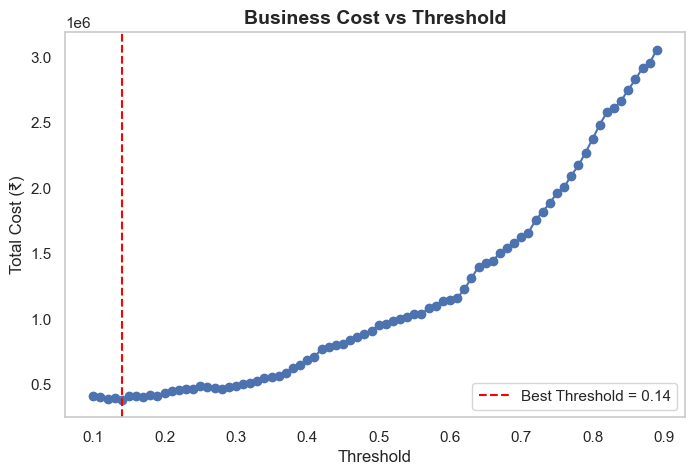

✅ Business cost analysis completed.



In [150]:
# ============================================================
# SECTION 27: COST-SENSITIVE BUSINESS ANALYSIS
# ============================================================

start_timer("Section 27")

"""
Purpose:
--------
- Evaluate model performance from a business perspective
- Minimize financial loss due to wrong predictions

Key Idea:
---------
- False Negative (missed churner) is very costly
- False Positive (unnecessary offer) is less costly
"""

print("💰 Performing cost-sensitive business analysis...\n")


# --------- COST DEFINITIONS ----------
COST_FN = 10000   # Missing a churner (very expensive)
COST_FP = 500     # Giving offer to non-churner (less expensive)


# --------- COST FUNCTION ----------
def calculate_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * COST_FN + fp * COST_FP


# --------- BASELINE (DEFAULT THRESHOLD = 0.5) ----------
y_pred_default = (y_prob_tuned >= 0.5).astype(int)
cost_default = calculate_cost(y_test, y_pred_default)


# --------- OPTIMIZE THRESHOLD ----------
thresholds = np.arange(0.1, 0.9, 0.01)

cost_results = []

best_cost = float("inf")
best_t = 0

for t in thresholds:
    y_pred = (y_prob_tuned >= t).astype(int)
    cost = calculate_cost(y_test, y_pred)
    
    cost_results.append({
        "Threshold": t,
        "Cost": cost
    })
    
    if cost < best_cost:
        best_cost = cost
        best_t = t


# --------- RESULTS ----------
cost_df = pd.DataFrame(cost_results)

print(f"📌 Default Threshold (0.5) Cost: ₹{cost_default:,.0f}")
print(f"🏆 Optimal Threshold: {best_t:.2f}")
print(f"💰 Minimum Cost: ₹{best_cost:,.0f}\n")
print(f"💸 Cost Reduction: ₹{cost_default - best_cost:,.0f}")

# --------- VISUALIZATION ----------
plt.figure(figsize=(8,5))

plt.plot(cost_df["Threshold"], cost_df["Cost"], marker='o')

plt.axvline(best_t, color='red', linestyle='--', label=f'Best Threshold = {best_t:.2f}')

plt.xlabel("Threshold")
plt.ylabel("Total Cost (₹)")
plt.title("Business Cost vs Threshold", fontsize=14, fontweight='bold')
plt.legend()
plt.grid()

plt.show()


print("✅ Business cost analysis completed.\n")

end_timer("Section 27")

In [151]:
# ============================================================
# SECTION 28: MODEL SAVING (DEPLOYMENT READY)
# ============================================================

start_timer("Section 28")
"""
Purpose:
--------
- Save trained model for future use
- Enables deployment without retraining

What is saved?
--------------
- Final selected model (based on cost optimization)
- Decision threshold (for classification)
"""

import pickle
import os
os.makedirs("models", exist_ok=True)

MODEL_PATH = "models/churn_model.pkl"

print("🔍 Final model type:", type(final_model))

print("Best model name:", best_model["Model"])
print("Final model object:", final_model)

# --------- SAVE MODEL + THRESHOLD ----------
SAVE_OBJECT = {
    "model": final_model,
    "threshold": final_threshold
}

with open(MODEL_PATH, "wb") as f:
    pickle.dump(SAVE_OBJECT, f)

print(f"✅ Model + threshold saved successfully at: {MODEL_PATH}")

# --------- LOAD MODEL ----------
with open(MODEL_PATH, "rb") as f:
    saved_obj = pickle.load(f)

loaded_model = saved_obj["model"]
loaded_threshold = saved_obj["threshold"]

print(f"📌 Loaded Threshold: {loaded_threshold:.2f}")

# ============================================================
# FINAL INFERENCE FUNCTION (PRODUCTION READY)
# ============================================================

def predict_churn(input_df, model, threshold):
    """
    Predict churn for new data

    Steps:
    -------
    1. Apply feature engineering
    2. Generate probabilities
    3. Apply threshold
    """

    # --------- FEATURE ENGINEERING ----------
    if "OnlineSecurity" in input_df.columns:
        input_df = feature_engineering(input_df)

    # --------- PREDICT ----------
    probs = model.predict_proba(input_df)[:, 1]
    preds = (probs >= threshold).astype(int)

    return preds, probs


# --------- EXAMPLE PREDICTION ----------
sample_probs = loaded_model.predict_proba(X_test)[:, 1]
sample_preds = (sample_probs >= loaded_threshold).astype(int)

print("✅ Predictions generated using optimal threshold")

sample_preds, sample_probs = predict_churn(X_test.copy(), loaded_model, loaded_threshold)

print("Sample Predictions:", sample_preds[:5])
print("Sample Probabilities:", sample_probs[:5])

end_timer("Section 28")

🔍 Final model type: <class 'sklearn.pipeline.Pipeline'>
Best model name: Logistic Regression
Final model object: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1))])
✅ Model + threshold saved successfully at: models/churn_model.pkl
📌 Loaded Threshold: 0.13
✅ Predictions generated using optimal threshold
Sample Predictions: [0 1 1 1 0]
Sample Probabilities: [0.11792644 0.81016793 0.13390984 0.59385709 0.07748757]



🔍 Explaining prediction for sample index: 0

⚠️ Pipeline detected — extracting model for SHAP...
⚠️ TreeExplainer not supported — using KernelExplainer (slower)


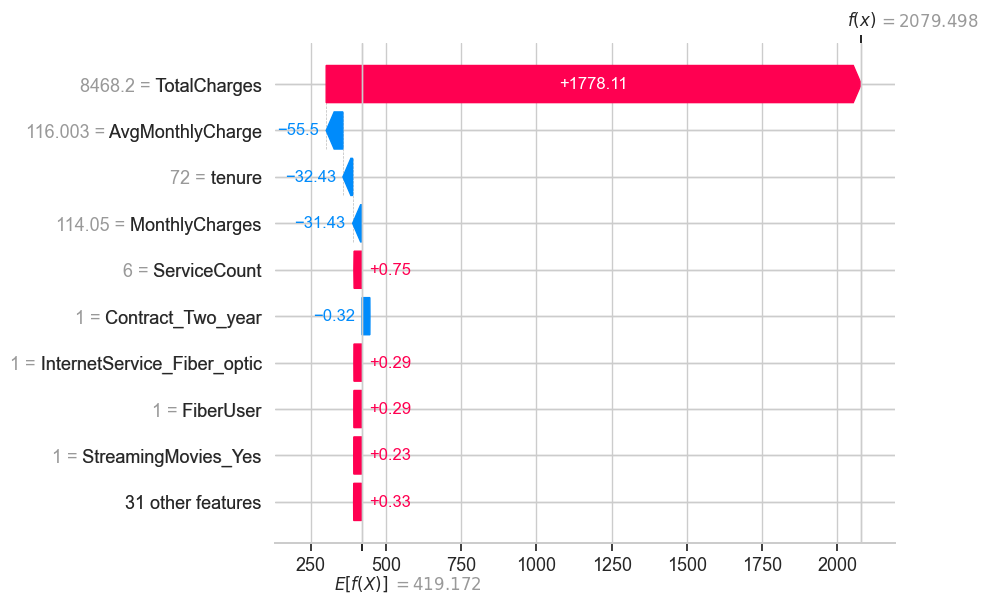

Model Prediction Probability: 1.0


In [152]:
# ============================================================
# SECTION 29: SHAP - SINGLE PREDICTION EXPLANATION
# ============================================================

start_timer("Section 29")

def explain_single_prediction(index, model, model_type="tree"):
    """
    Explain a single prediction using SHAP.

    Supports:
    ----------
    - Tree models (XGBoost, RF, LightGBM, CatBoost)
    - Pipelines (automatically extracts model)
    """

    import shap

    print(f"\n🔍 Explaining prediction for sample index: {index}\n")

    # --------- SAFETY CHECK ----------
    if index >= len(X_test):
        raise IndexError(f"Index {index} out of range for X_test of size {len(X_test)}")

    # --------- HANDLE PIPELINE ----------
    if hasattr(model, "named_steps"):
        print("⚠️ Pipeline detected — extracting model for SHAP...")
        model = model.named_steps["model"]

    # --------- SELECT SAMPLE ----------
    if model_type == "catboost":
        sample = X_cat.loc[[X_test.index[index]]]
    else:
        sample = X_test.iloc[[index]].copy().astype(float)

    # --------- SELECT CORRECT EXPLAINER ----------
    try:
        explainer = shap.TreeExplainer(model)
    except:
        print("⚠️ TreeExplainer not supported — using KernelExplainer (slower)")
        explainer = shap.Explainer(model, X_test)

    shap_values = explainer(sample)

    # --------- HANDLE SHAP OUTPUT ----------
    if len(shap_values.values.shape) == 3:
        shap_value_single = shap_values.values[0, :, 1]
        base_value = shap_values.base_values[0][1]
    else:
        shap_value_single = shap_values.values[0]
        base_value = shap_values.base_values[0]

    # --------- WATERFALL PLOT ----------
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_value_single,
            base_values=base_value,
            data=sample.iloc[0],
            feature_names=sample.columns
        )
    )

    # --------- MODEL PREDICTION ----------
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(sample)[0][1]
        print("Model Prediction Probability:", prob)
    else:
        print("⚠️ Model does not support predict_proba()")


# --------- CALL FUNCTION ----------
explain_single_prediction(0, final_model)

end_timer("Section 29")


🔍 Explaining prediction for sample index: 0



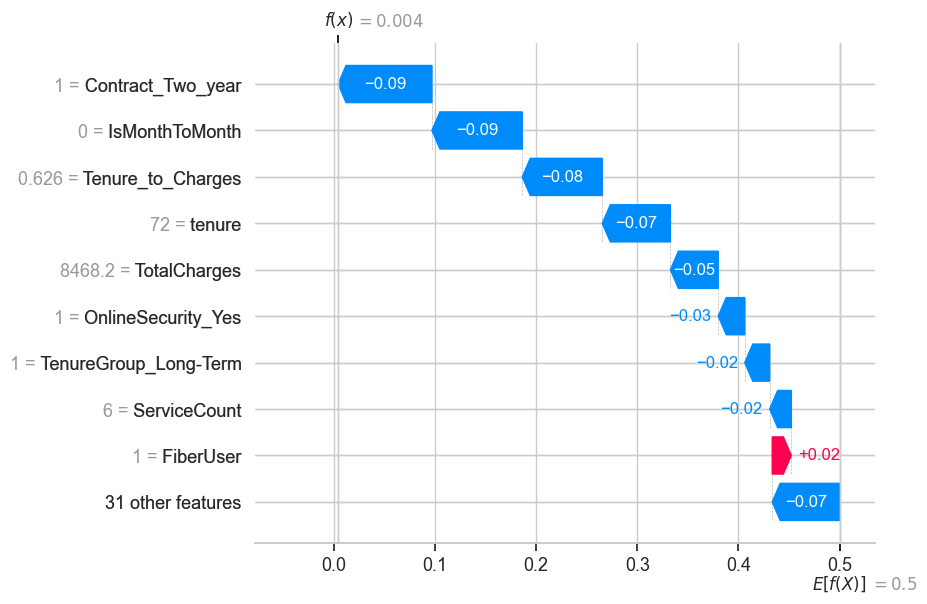

Model Prediction Probability: 0.004325985189196583

🔍 Explaining prediction for sample index: 0



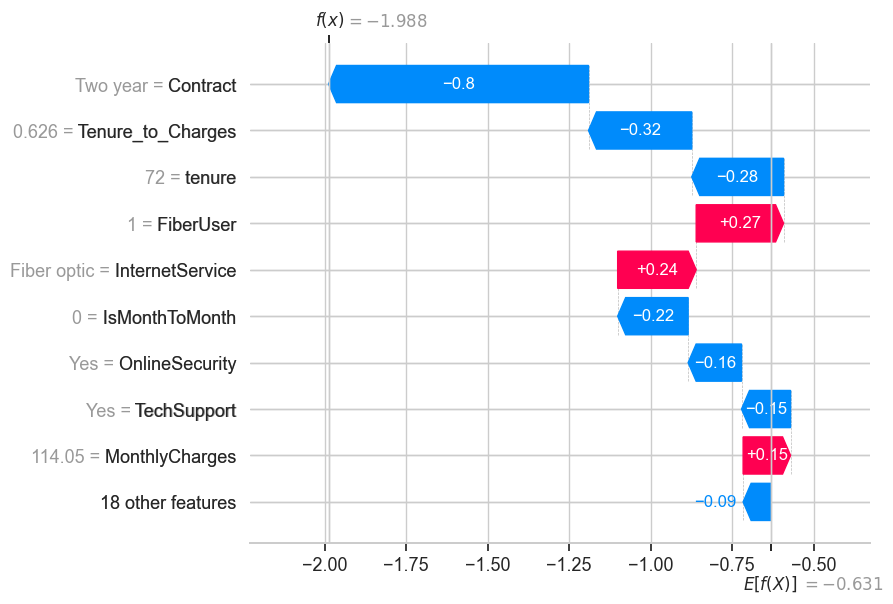

Model Prediction Probability: 0.12049112255104866


In [153]:
explain_single_prediction(0, rf_weighted)
explain_single_prediction(0, cat_model, model_type="catboost")



🌍 Generating global SHAP summary...

⚠️ Pipeline detected — extracting model for SHAP...
⚠️ TreeExplainer not supported — using general Explainer (slower)


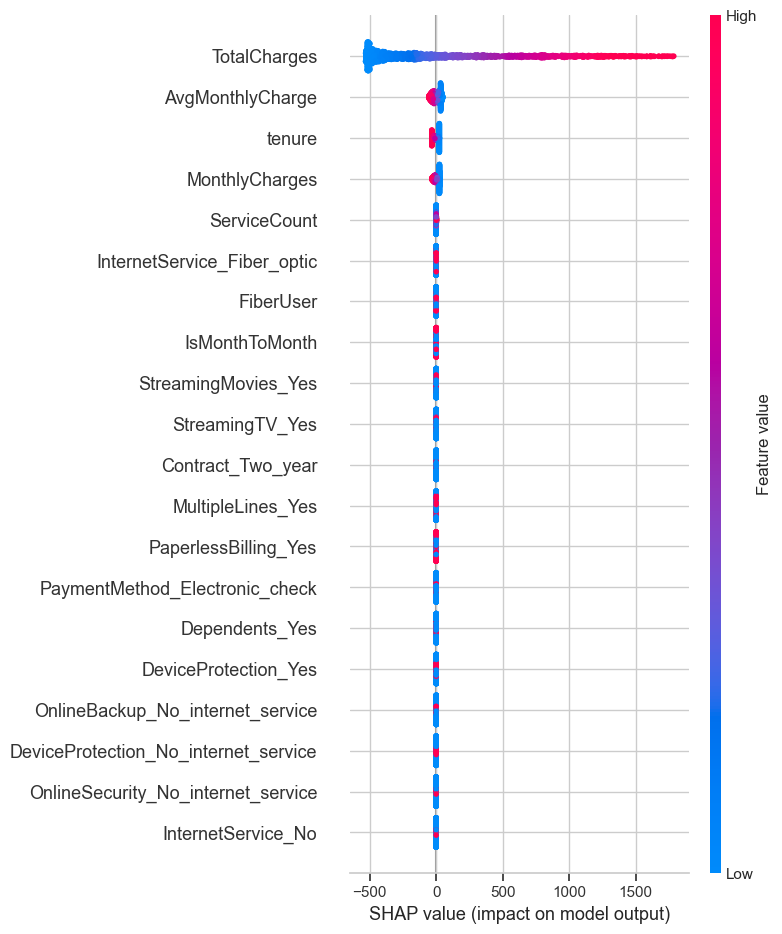

In [154]:
# ============================================================
# SECTION 30: SHAP - GLOBAL EXPLANATION
# ============================================================

start_timer("Section 30")

def explain_global(model):
    """
    Global feature importance using SHAP

    Supports:
    ----------
    - Tree models (XGBoost, RF, LightGBM, CatBoost)
    - Pipelines (auto extracts model)
    """

    import shap

    print("\n🌍 Generating global SHAP summary...\n")

    # --------- HANDLE PIPELINE ----------
    if hasattr(model, "named_steps"):
        print("⚠️ Pipeline detected — extracting model for SHAP...")
        model = model.named_steps["model"]

    # --------- ENSURE NUMERIC DATA ----------
    X_numeric = X_test.copy()

    # Convert everything to numeric (critical fix)
    X_numeric = X_numeric.astype(float)

    # --------- SELECT EXPLAINER ----------
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_numeric)
    except:
        print("⚠️ TreeExplainer not supported — using general Explainer (slower)")
        explainer = shap.Explainer(model, X_numeric)
        shap_values = explainer(X_numeric)

    # --------- HANDLE SHAPE ----------
    if len(shap_values.values.shape) == 3:
        shap_values_to_plot = shap_values.values[:, :, 1]
    else:
        shap_values_to_plot = shap_values.values

    # --------- SUMMARY PLOT ----------
    shap.summary_plot(
        shap_values_to_plot,
        X_numeric,
        feature_names=X_numeric.columns
    )


# --------- CALL FUNCTION ----------
explain_global(final_model)

end_timer("Section 30")

In [155]:
# ============================================================
# FINAL TIMING SUMMARY
# ============================================================

end_total_time = time.time()
total_time = end_total_time - start_total_time

print("\n⏱️ EXECUTION TIME SUMMARY\n")

# Sort by time (slowest first)
sorted_sections = sorted(
    section_times.items(),
    key=lambda x: x[1].get("duration", 0),
    reverse=True
)

for section, timing in sorted_sections:
    duration = timing.get("duration", None)
    name = section_names.get(section, "Unknown Section")
    
    if duration is not None:
        print(f"{section} ({name}): {duration:.2f} sec")
    else:
        print(f"{section} ({name}): ❌ Not completed")

print("\n--------------------------------------")
print(f"🚀 TOTAL EXECUTION TIME: {total_time:.2f} seconds")


⏱️ EXECUTION TIME SUMMARY

Section 15 (CATBOOST): 217.27 sec
Section 16 (STACKING): 138.13 sec
Section 23 (SHAP): 55.62 sec
Section 20 (OPTUNA TUNING): 21.17 sec
Section 12 (RANDOM FOREST): 16.42 sec
Section 14 (LIGHTGBM): 14.65 sec
Section 19 (FINAL CV CHECK): 14.46 sec
Section 13 (XGBOOST): 6.33 sec
Section 24 (ANN TRAINING): 4.25 sec
Section 26 (FINAL SUMMARY): 1.38 sec
Section 4 (EDA): 0.72 sec
Section 30 (SHAP GLOBAL): 0.63 sec
Section 18 (THRESHOLD OPTIMIZATION): 0.53 sec
Section 11 (DECISION TREE): 0.47 sec
Section 10 (LOGISTIC REGRESSION): 0.43 sec
Section 17 (MODEL COMPARISON): 0.38 sec
Section 21 (TUNED LOGISTIC): 0.33 sec
Section 29 (SHAP SINGLE): 0.27 sec
Section 22 (THRESHOLD (TUNED)): 0.27 sec
Section 27 (BUSINESS ANALYSIS): 0.19 sec
Section 3 (DATA LOADING): 0.15 sec
Section 7 (ENCODING): 0.05 sec
Section 8 (SPLIT & SCALING): 0.04 sec
Section 5 (DATA CLEANING): 0.03 sec
Section 6 (FEATURE ENGINEERING): 0.02 sec
Section 2 (IMPORTS & CONFIG): 0.02 sec
Section 28 (MODEL SA